# Notebook 1 — BDD100K | Car Detection Training
**Train YOLOv8n on BDD100K (car only)**




In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Section 1 — Install & Import

In [17]:
!pip install ultralytics mlflow kagglehub opencv-python-headless matplotlib pyyaml tqdm -q

import os, json, shutil, yaml, warnings
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
import mlflow
import kagglehub
from tqdm import tqdm
from ultralytics import YOLO
import pickle

warnings.filterwarnings('ignore')


In [18]:
import ultralytics
print(ultralytics.__version__)

8.4.33


##  Section 2 — Configuration

In [19]:

BDD_DIR     = '/content/datasets/bdd100k'
MODELS_DIR  = '/content/bdd100k_models'
RESULTS_DIR = '/content/bdd100k_results'

for d in [BDD_DIR, MODELS_DIR, RESULTS_DIR,
          f'{BDD_DIR}/images/train', f'{BDD_DIR}/images/val',
          f'{BDD_DIR}/labels/train', f'{BDD_DIR}/labels/val']:
    os.makedirs(d, exist_ok=True)


TRAIN_CFG = {
    'epochs'   : 15,
    'imgsz'    : 640,
    'batch'    : 8,
    'lr0'      : 0.01,
    'patience' : 5,
    'device'   : 0,
    'conf'     : 0.25,
    'iou'      : 0.45,
}

MODELS = ['yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt']

print('Config ready')
print(f'Dataset dir : {BDD_DIR}')
print(f'Models      : {MODELS}')
print(f'Epochs      : {TRAIN_CFG["epochs"]}')

Config ready
Dataset dir : /content/datasets/bdd100k
Models      : ['yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt']
Epochs      : 15


##  Section 3 — Download BDD100K from Kaggle

In [20]:

print('Downloading BDD100K...')
bdd_raw = kagglehub.dataset_download('solesensei/solesensei_bdd100k')
print(f'Downloaded to: {bdd_raw}')

print('\nContents:')
for item in sorted(os.listdir(bdd_raw))[:10]:
    print(f'   {item}')

Using Colab cache for faster access to the 'solesensei_bdd100k' dataset.
Downloaded to: /kaggle/input/solesensei_bdd100k

Contents:
   bdd100k
   bdd100k_labels_release
   bdd100k_seg


##  Section 4 — Convert JSON → YOLO Format (car only)

In [ ]:
import os
import json
import shutil
from tqdm import tqdm

DRIVE_ROOT = "/content/BDD100K_Project"
BDD_DIR    = f"{DRIVE_ROOT}/bdd_yolo_dataset"

os.makedirs(BDD_DIR, exist_ok=True)


def find_file(root, keyword, ext):
    for r, _, files in os.walk(root):
        for f in files:
            if keyword in f and f.endswith(ext):
                return os.path.join(r, f)
    return None


def build_image_index(root):
    image_index = {}
    print(" Building image index...")
    for r, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                image_index[f] = os.path.join(r, f)
    print(f" Indexed {len(image_index):,} images")
    return image_index


def convert_bdd_fast(raw_path, out_dir):

    IMG_W, IMG_H = 1280, 720
    summary = {}

    image_index = build_image_index(raw_path)

    for split in ["train", "val"]:

        json_path = find_file(raw_path, split, ".json")
        if not json_path:
            print(f" {split} JSON not found")
            continue

        lbl_dir = f"{out_dir}/labels/{split}"
        img_dir = f"{out_dir}/images/{split}"

        os.makedirs(lbl_dir, exist_ok=True)
        os.makedirs(img_dir, exist_ok=True)

        with open(json_path, "r") as f:
            data = json.load(f)

        boxes, imgs = 0, 0

        for item in tqdm(data, desc=f"BDD {split}"):
            name = item["name"]
            txt_name = name.rsplit(".", 1)[0] + ".txt"
            label_path = os.path.join(lbl_dir, txt_name)
            dst_img_path = os.path.join(img_dir, name)

            lines = []

            for lbl in item.get("labels", []):
                if lbl.get("category") != "car":
                    continue

                b = lbl.get("box2d")
                if not b or b["x2"] <= b["x1"] or b["y2"] <= b["y1"]:
                    continue

                cx = ((b["x1"] + b["x2"]) / 2) / IMG_W
                cy = ((b["y1"] + b["y2"]) / 2) / IMG_H
                w  = (b["x2"] - b["x1"]) / IMG_W
                h  = (b["y2"] - b["y1"]) / IMG_H

                lines.append(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
                boxes += 1

            with open(label_path, "w") as f:
                f.write("\n".join(lines))

            src_img_path = image_index.get(name)
            if src_img_path:
                if not os.path.exists(dst_img_path):
                    shutil.copy2(src_img_path, dst_img_path)
                imgs += 1

        summary[split] = {"images": imgs, "boxes": boxes}
        print(f"{split}: {imgs:,} images | {boxes:,} car boxes")

    return summary


# ----------------------------------------

print(" Converting BDD100K → YOLO")
bdd_summary = convert_bdd_fast(bdd_raw, BDD_DIR)
print(" Done!")

 Converting BDD100K → YOLO
 Building image index...
 Indexed 121,750 images


BDD train: 100%|██████████| 69863/69863 [03:56<00:00, 295.99it/s]


train: 69,863 images | 713,211 car boxes


BDD val: 100%|██████████| 10000/10000 [00:33<00:00, 301.75it/s]


val: 10,000 images | 102,506 car boxes
 Done!


In [ ]:
DRIVE_ROOT = "/content/drive/MyDrive/BDD100K_Project"
BDD_DIR    = f"{DRIVE_ROOT}/bdd_yolo_dataset"

os.makedirs(BDD_DIR, exist_ok=True)


def find_file(root, keyword, ext):
    for r, _, files in os.walk(root):
        for f in files:
            if keyword in f and f.endswith(ext):
                return os.path.join(r, f)
    return None



def build_image_index(root):
    image_index = {}
    print(" Building image index...")
    for r, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                image_index[f] = os.path.join(r, f)
    print(f"  Indexed {len(image_index):,} images")
    return image_index


def convert_bdd_fast(raw_path, out_dir):

    IMG_W, IMG_H = 1280, 720
    summary = {}


    image_index = build_image_index(raw_path)

    for split in ["train", "val"]:

        json_path = find_file(raw_path, split, ".json")
        if not json_path:
            print(f" {split} JSON not found")
            continue

        lbl_dir = f"{out_dir}/labels/{split}"
        img_dir = f"{out_dir}/images/{split}"

        os.makedirs(lbl_dir, exist_ok=True)
        os.makedirs(img_dir, exist_ok=True)

        with open(json_path, "r") as f:
            data = json.load(f)

        boxes, imgs = 0, 0

        for item in tqdm(data, desc=f"BDD {split}"):
            name = item["name"]
            txt_name = name.rsplit(".", 1)[0] + ".txt"
            label_path = os.path.join(lbl_dir, txt_name)
            dst_img_path = os.path.join(img_dir, name)

            lines = []

            for lbl in item.get("labels", []):
                if lbl.get("category") != "car":
                    continue

                b = lbl.get("box2d")
                if not b or b["x2"] <= b["x1"] or b["y2"] <= b["y1"]:
                    continue

                cx = ((b["x1"] + b["x2"]) / 2) / IMG_W
                cy = ((b["y1"] + b["y2"]) / 2) / IMG_H
                w  = (b["x2"] - b["x1"]) / IMG_W
                h  = (b["y2"] - b["y1"]) / IMG_H

                lines.append(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
                boxes += 1


            with open(label_path, "w") as f:
                f.write("\n".join(lines))


            src_img_path = image_index.get(name)
            if src_img_path:
                if not os.path.exists(dst_img_path):
                    shutil.copy2(src_img_path, dst_img_path)
                imgs += 1

        summary[split] = {"images": imgs, "boxes": boxes}
        print(f"{split}: {imgs:,} images | {boxes:,} car boxes")

    return summary

# ----------------------------------------
print("Converting BDD100K → YOLO")
bdd_summary = convert_bdd_fast(bdd_raw, BDD_DIR)
print("Done!")

In [ ]:
def find_file(root, keyword, ext):

    for r, _, files in os.walk(root):
        for f in files:
            if keyword in f and f.endswith(ext):
                return os.path.join(r, f)
    return None


def convert_bdd(raw_path, out_dir):
    IMG_W, IMG_H = 1280, 720
    summary = {}

    for split in ['train', 'val']:
        json_path = find_file(raw_path, split, '.json')
        if not json_path:
            print(f'   {split} JSON not found')
            continue

        lbl_dir = f'{out_dir}/labels/{split}'
        img_dir = f'{out_dir}/images/{split}'

        with open(json_path) as f:
            data = json.load(f)

        boxes, imgs = 0, 0

        for item in tqdm(data, desc=f'  BDD {split}'):
            name  = item['name']
            lines = []

            for lbl in item.get('labels', []):
                if lbl.get('category') != 'car':
                    continue
                b = lbl.get('box2d')
                if not b or b['x2'] <= b['x1'] or b['y2'] <= b['y1']:
                    continue
                cx = max(0, min(1, ((b['x1']+b['x2'])/2) / IMG_W))
                cy = max(0, min(1, ((b['y1']+b['y2'])/2) / IMG_H))
                w  = max(0, min(1, (b['x2']-b['x1'])     / IMG_W))
                h  = max(0, min(1, (b['y2']-b['y1'])     / IMG_H))
                lines.append(f'0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')
                boxes += 1

            with open(f'{lbl_dir}/{name.replace(".jpg",".txt")}', 'w') as f:
                f.write('\n'.join(lines))

            # Copy image
            for r, _, files in os.walk(raw_path):
                if name in files:
                    dst = f'{img_dir}/{name}'
                    if not os.path.exists(dst):
                        shutil.copy2(os.path.join(r, name), dst)
                    imgs += 1
                    break

        summary[split] = {'images': imgs, 'boxes': boxes}
        print(f'  {split}: {imgs:,} images | {boxes:,} car boxes')

    return summary


print('Converting BDD100K → YOLO...')
bdd_summary = convert_bdd(bdd_raw, BDD_DIR)
print('Done!')

## Section 5 — Generate YAML

In [23]:
BDD_YAML = f'{BDD_DIR}/bdd100k_car.yaml'

with open(BDD_YAML, 'w') as f:
    yaml.dump({'path': BDD_DIR, 'train': 'images/train',
               'val': 'images/val', 'nc': 1, 'names': ['car']}, f)

print(f'YAML saved: {BDD_YAML}')
print(f'Train images : {len(os.listdir(BDD_DIR+"/images/train")):,}')
print(f'Val   images : {len(os.listdir(BDD_DIR+"/images/val")):,}')

YAML saved: /content/BDD100K_Project/bdd_yolo_dataset/bdd100k_car.yaml
Train images : 69,863
Val   images : 10,000


### save data to drive for faster

##  Section 6 — Train 3 Models with MLflow

In [24]:
import os
import json
import shutil
import pickle
from ultralytics import YOLO

last_pt = "/content/drive/MyDrive/BDD100K_Project/models/BDD100K_yolov8n/weights/last.pt"

print("Resuming from:", last_pt)
print("Exists?", os.path.exists(last_pt))


model_name = 'yolov8n.pt'   # غيريه بعدين إلى yolov8s.pt أو yolov8m.pt
short = model_name.replace('.pt', '')
run_name = f'BDD100K_{short}'


# Google Drive

DRIVE_ROOT  = "/content/drive/MyDrive/BDD100K_Project"
MODELS_DIR  = f"{DRIVE_ROOT}/models"
RESULTS_DIR = f"{DRIVE_ROOT}/results"
BACKUP_DIR  = f"{DRIVE_ROOT}/weights_backup"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(BACKUP_DIR, exist_ok=True)

print(f" Training: {run_name}")

#  التدريب

# model = YOLO(model_name)

model = YOLO(last_pt)


model.train(
    data     = BDD_YAML,
    epochs   = TRAIN_CFG['epochs'],
    imgsz    = TRAIN_CFG['imgsz'],
    batch    = TRAIN_CFG['batch'],
    patience = TRAIN_CFG['patience'],
    device   = TRAIN_CFG['device'],
    project  = MODELS_DIR,
    name     = run_name,
    exist_ok = True,
    plots    = True,
    save     = True,
    verbose  = False,
    workers  = 2,
    resume=True

)

best_pt = f"{MODELS_DIR}/{run_name}/weights/best.pt"
last_pt = f"{MODELS_DIR}/{run_name}/weights/last.pt"

# التقييم

val_model = YOLO(best_pt)
val = val_model.val(
    data    = BDD_YAML,
    imgsz   = TRAIN_CFG['imgsz'],
    conf    = TRAIN_CFG['conf'],
    iou     = TRAIN_CFG['iou'],
    device  = TRAIN_CFG['device'],
    verbose = False,
)

metrics = {
    'run_name' : run_name,
    'dataset'  : 'BDD100K',
    'model'    : short,
    'view'     : 'dashcam',
    'best_pt'  : best_pt,
    'last_pt'  : last_pt,
    'mAP50'    : round(val.box.map50, 4),
    'mAP50_95' : round(val.box.map,   4),
    'precision': round(val.box.mp,    4),
    'recall'   : round(val.box.mr,    4),
}

#  حفظ  في Google Drive
run_save_dir = f"{BACKUP_DIR}/{run_name}"
os.makedirs(run_save_dir, exist_ok=True)

if os.path.exists(best_pt):
    shutil.copy2(best_pt, f"{run_save_dir}/best.pt")

if os.path.exists(last_pt):
    shutil.copy2(last_pt, f"{run_save_dir}/last.pt")

files_to_copy = [
    f"{MODELS_DIR}/{run_name}/results.png",
    f"{MODELS_DIR}/{run_name}/labels.jpg",
    f"{MODELS_DIR}/{run_name}/args.yaml",
    f"{MODELS_DIR}/{run_name}/results.csv",
]

for file_path in files_to_copy:
    if os.path.exists(file_path):
        shutil.copy2(file_path, run_save_dir)

with open(f"{run_save_dir}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

with open(f"{RESULTS_DIR}/{run_name}_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print(f"mAP@50 : {metrics['mAP50']}")
print(f"mAP@50-95: {metrics['mAP50_95']}")
print(f"Precision : {metrics['precision']}")
print(f"Recall  : {metrics['recall']}")
print(f"Saved to: {run_save_dir}")

Resuming from: /content/drive/MyDrive/BDD100K_Project/models/BDD100K_yolov8n/weights/last.pt
Exists? True
 Training: BDD100K_yolov8n
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BDD100K_Project/bdd_yolo_dataset/bdd100k_car.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDr

2026/04/02 18:46:02 INFO mlflow.tracking.fluent: Experiment with name '/content/drive/MyDrive/BDD100K_Project/models' does not exist. Creating a new experiment.
2026/04/02 18:46:02 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/04/02 18:46:02 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.


MLflow: logging run_id(dd657e029f4b4f10bf088c111fe56787) to runs/mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs/mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /content/drive/MyDrive/BDD100K_Project/models/BDD100K_yolov8n
Starting training for 10 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       6/10      1.98G      1.263      0.702     0.9883         97        640: 100% ━━━━━━━━━━━━ 8733/8733 5.0it/s 28:54
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 7.1it/s 1:29
                   all      10000     102506      0.804      0.625       0.72      0.435

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       7/10      1.98G      1.263     0.6969     0.9875        131        640: 100% ━━━━━━━━━━━━ 8733/8733 5.1it/s 2

##  Section 7 — BDD100K Results Summary

In [25]:
print('  BDD100K — Result Summary')


r = metrics

print(f"Model      : {r['model']}")
print(f"mAP@50     : {r['mAP50']}")
print(f"mAP@50-95  : {r['mAP50_95']}")
print(f"Precision  : {r['precision']}")
print(f"Recall     : {r['recall']}")

print('═'*55)

# Save results


os.makedirs(RESULTS_DIR, exist_ok=True)

with open(f'{RESULTS_DIR}/bdd_result.pkl', 'wb') as f:
    pickle.dump(r, f)

with open(f'{RESULTS_DIR}/bdd_result.json', 'w') as f:
    json.dump(r, f, indent=4)

# Save best model path
with open(f'{RESULTS_DIR}/best_bdd_path.txt', 'w') as f:
    f.write(r['best_pt'])

print(f'\nResults saved → {RESULTS_DIR}/bdd_result.pkl')
print(f'Best model: {r["model"]} | mAP@50 = {r["mAP50"]}')

  BDD100K — Result Summary
Model      : yolov8n
mAP@50     : 0.7742
mAP@50-95  : 0.5299
Precision  : 0.7987
Recall     : 0.6684
═══════════════════════════════════════════════════════

Results saved → /content/drive/MyDrive/BDD100K_Project/results/bdd_result.pkl
Best model: yolov8n | mAP@50 = 0.7742


##  Section 8 — Training Curves

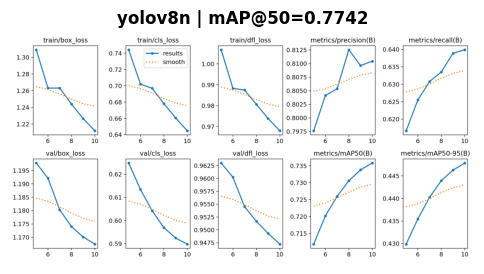

Training curve saved → /content/drive/MyDrive/BDD100K_Project/results/training_curve.png


In [27]:


plot_path = f"{MODELS_DIR}/{r['run_name']}/results.png"

plt.figure(figsize=(6,5))

if os.path.exists(plot_path):
    img = mpimg.imread(plot_path)
    plt.imshow(img)
    plt.title(f"{r['model']} | mAP@50={r['mAP50']}", fontweight='bold')
else:
    plt.text(0.5, 0.5, 'Plot not found', ha='center', va='center')

plt.axis('off')

# حفظ الصورة
save_path = f"{RESULTS_DIR}/training_curve.png"
plt.savefig(save_path, dpi=120, bbox_inches='tight')

plt.show()

print(f'Training curve saved → {save_path}')